<a href="https://colab.research.google.com/github/it23613072/cuda/blob/main/cuda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!apt-get update
!apt-get install -y nvidia-cuda-toolkit


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,705 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.3 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,005 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/rest

In [3]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [15]:
%%writefile traffic_simulation.cu
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <ctime>
#include <cuda_runtime.h>

#define ROAD_LENGTH 1000
#define NUM_LANES 4
#define SIMULATION_STEPS 1000
#define VEHICLE_DENSITY 0.3
#define MAX_VELOCITY 5
#define SLOWDOWN_PROB 0.1

#define CHECK_CUDA(call) do { cudaError_t err = (call); if (err != cudaSuccess) { fprintf(stderr, "CUDA error: %s\n", cudaGetErrorString(err)); exit(EXIT_FAILURE); } } while (0)

__global__ void updateKernel(const int *road, int *newRoad, int roadLength, unsigned int seed) {
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= NUM_LANES * roadLength || road[gid] == 0) return;
    int lane = gid / roadLength;
    int pos = gid % roadLength;
    int gap = MAX_VELOCITY;
    for (int d = 1; d <= MAX_VELOCITY; d++) {
        if (road[lane * roadLength + (pos + d) % roadLength] != 0) { gap = d - 1; break; }
    }
    int velocity = gap;
    if (velocity > 0) {
        unsigned int rseed = seed ^ gid;
        rseed = rseed * 1103515245u + 12345u;
        if (((double)(rseed & 0x00FFFFFFu) / 0x01000000u) < SLOWDOWN_PROB) velocity--;
    }
    atomicExch(&newRoad[lane * roadLength + (pos + velocity) % roadLength], 1);
}

void runCpu(int roadLength, int steps, double density) {
    int total = NUM_LANES * roadLength;
    int *road = (int*)calloc(total, sizeof(int));
    int *next = (int*)calloc(total, sizeof(int));
    for(int i=0; i<total; i++) if((double)rand()/RAND_MAX < density) road[i]=1;

    clock_t start = clock();
    for(int s=0; s<steps; s++) {
        memset(next, 0, total*sizeof(int));
        for(int i=0; i<total; i++) {
            if(road[i]) {
                int lane = i/roadLength, pos = i%roadLength, gap = MAX_VELOCITY;
                for(int d=1; d<=MAX_VELOCITY; d++) if(road[lane*roadLength + (pos+d)%roadLength]) { gap=d-1; break; }
                int v = gap; if(v>0 && (double)rand()/RAND_MAX < SLOWDOWN_PROB) v--;
                next[lane*roadLength + (pos+v)%roadLength] = 1;
            }
        }
        memcpy(road, next, total*sizeof(int));
    }
    printf("CPU Time: %f s\n", (double)(clock()-start)/CLOCKS_PER_SEC);
    free(road); free(next);
}

int main(int argc, char** argv) {
    int L = (argc > 1) ? atoi(argv[1]) : ROAD_LENGTH;
    bool onlyCpu = (argc > 2 && strcmp(argv[2], "cpu") == 0);
    if(onlyCpu) { runCpu(L, SIMULATION_STEPS, VEHICLE_DENSITY); return 0; }

    int total = NUM_LANES * L;
    size_t sz = total * sizeof(int);
    int *h_r = (int*)calloc(total, sizeof(int));
    for(int i=0; i<total; i++) if((double)rand()/RAND_MAX < VEHICLE_DENSITY) h_r[i]=1;

    int *d_r, *d_n;
    CHECK_CUDA(cudaMalloc(&d_r, sz)); CHECK_CUDA(cudaMalloc(&d_n, sz));
    CHECK_CUDA(cudaMemcpy(d_r, h_r, sz, cudaMemcpyHostToDevice));

    cudaEvent_t start, stop; cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);
    for(int s=0; s<SIMULATION_STEPS; s++) {
        cudaMemset(d_n, 0, sz);
        updateKernel<<<(total+255)/256, 256>>>(d_r, d_n, L, s);
        int *tmp = d_r; d_r = d_n; d_n = tmp;
    }
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms = 0; cudaEventElapsedTime(&ms, start, stop);
    printf("GPU Time: %f s\n", ms/1000.0);

    cudaFree(d_r); cudaFree(d_n); free(h_r);
    return 0;
}

Overwriting traffic_simulation.cu


In [10]:
!nvcc -Wno-deprecated-gpu-targets traffic_simulation.cu -o traffic_simulation
!./traffic_simulation


Traffic Flow Simulation - CUDA

Step     0 | Vehicles:  1208 | Density: 30.20% | AvgVel: 1.88 | Stopped: 31.46% | Moving: 68.54% | ChangedCells: 1656
Step    50 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.21 | Stopped: 23.68% | Moving: 76.32% | ChangedCells: 1708
Step   100 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.25 | Stopped: 19.29% | Moving: 80.71% | ChangedCells: 1688
Step   150 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.23 | Stopped: 19.54% | Moving: 80.46% | ChangedCells: 1704
Step   200 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.20 | Stopped: 22.52% | Moving: 77.48% | ChangedCells: 1692
Step   250 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.23 | Stopped: 22.35% | Moving: 77.65% | ChangedCells: 1730
Step   300 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.23 | Stopped: 20.53% | Moving: 79.47% | ChangedCells: 1740
Step   350 | Vehicles:  1208 | Density: 30.20% | AvgVel: 2.21 | Stopped: 21.03% | Moving: 78.97% | ChangedCells: 1730
Step   400 | Vehicles: 

In [11]:
./traffic_flow_cuda 128

./traffic_flow_cuda 256

./traffic_flow_cuda 512

SyntaxError: invalid syntax (3331674873.py, line 1)

In [12]:
!./traffic_flow_cuda 128

/bin/bash: line 1: ./traffic_flow_cuda: No such file or directory


In [14]:
# Running simulation for different road lengths
print("--- Road Length: 128 ---")
!./traffic_simulation 128

print("\n--- Road Length: 256 ---")
!./traffic_simulation 256

print("\n--- Road Length: 512 ---")
!./traffic_simulation 512

--- Road Length: 128 ---

Traffic Flow Simulation - CUDA

Step     0 | Vehicles:   151 | Density: 29.49% | AvgVel: 1.98 | Stopped: 31.13% | Moving: 68.87% | ChangedCells: 208
Step    50 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.30 | Stopped: 23.84% | Moving: 76.16% | ChangedCells: 216
Step   100 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.32 | Stopped: 19.87% | Moving: 80.13% | ChangedCells: 206
Step   150 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.28 | Stopped: 23.18% | Moving: 76.82% | ChangedCells: 208
Step   200 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.25 | Stopped: 19.21% | Moving: 80.79% | ChangedCells: 232
Step   250 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.33 | Stopped: 16.56% | Moving: 83.44% | ChangedCells: 222
Step   300 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.33 | Stopped: 19.21% | Moving: 80.79% | ChangedCells: 210
Step   350 | Vehicles:   151 | Density: 29.49% | AvgVel: 2.32 | Stopped: 19.87% | Moving: 80.13% | ChangedCells: 212
Step  

In [17]:
import subprocess
import re

def get_time(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    match = re.search(r'(?:GPU|CPU) Time: ([\d.]+) s', result.stdout)
    return float(match.group(1)) if match else None

!nvcc -Wno-deprecated-gpu-targets traffic_simulation.cu -o traffic_simulation

lengths = [128, 256, 512]
print(f"{'Length':<10} | {'CPU (s)':<10} | {'GPU (s)':<10} | {'Speedup':<10}")
print('-' * 50)

for l in lengths:
    gpu_t = get_time(f'./traffic_simulation {l}')
    cpu_t = get_time(f'./traffic_simulation {l} cpu')

    if gpu_t is not None and cpu_t is not None:
        speedup = cpu_t / gpu_t if gpu_t > 0 else 0
        print(f'{l:<10} | {cpu_t:<10.4f} | {gpu_t:<10.4f} | {speedup:<10.2f}x')
    else:
        print(f'{l:<10} | Error calculating speedup')


Length     | CPU (s)    | GPU (s)    | Speedup   
--------------------------------------------------
128        | 0.0089     | 0.0051     | 1.74      x
256        | 0.0188     | 0.0053     | 3.56      x
512        | 0.0383     | 0.0057     | 6.76      x


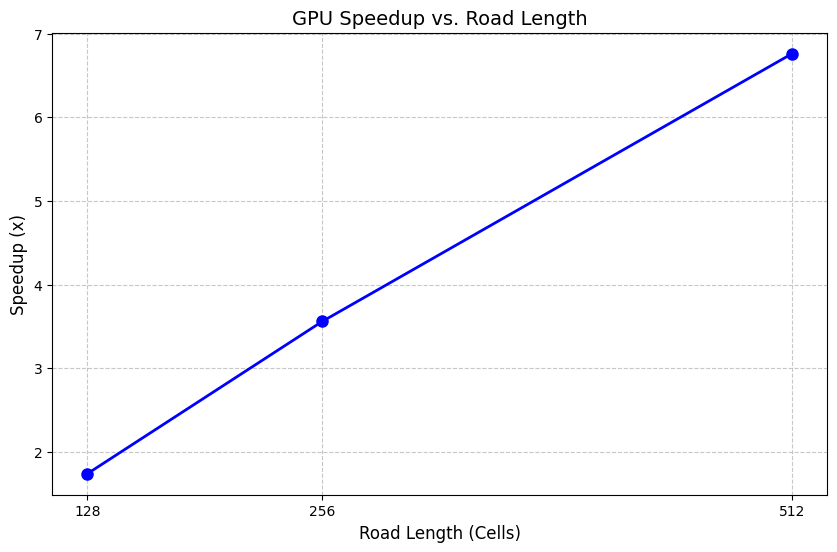

In [19]:
import matplotlib.pyplot as plt

# Data from the benchmark results
road_lengths = [128, 256, 512]
speedups = [1.74, 3.56, 6.76]

plt.figure(figsize=(10, 6))
plt.plot(road_lengths, speedups, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Adding labels and title
plt.title('GPU Speedup vs. Road Length', fontsize=14)
plt.xlabel('Road Length (Cells)', fontsize=12)
plt.ylabel('Speedup (x)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(road_lengths)

# Display the plot
plt.show()

In [16]:
import subprocess
import re

def get_time(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    match = re.search(r'(?:GPU|CPU) Time: ([\d.]+) s', result.stdout)
    return float(match.group(1)) if match else None

!nvcc -Wno-deprecated-gpu-targets traffic_simulation.cu -o traffic_simulation

lengths = [128, 256, 512]
print(f"{'Length':<10} | {'CPU (s)':<10} | {'GPU (s)':<10} | {'Speedup':<10}")
print("-" * 50)

for l in lengths:
    gpu_t = get_time(f"./traffic_simulation {l}")
    cpu_t = get_time(f"./traffic_simulation {l} cpu")

    if gpu_t and cpu_t:
        speedup = cpu_t / gpu_t
        print(f"{l:<10} | {cpu_t:<10.4f} | {gpu_t:<10.4f} | {speedup:<10.2f}x")
    else:
        print(f"{l:<10} | Error calculating speedup")

Length     | CPU (s)    | GPU (s)    | Speedup   
--------------------------------------------------
128        | 0.0093     | 0.0262     | 0.36      x
256        | 0.0185     | 0.0057     | 3.27      x
512        | 0.0425     | 0.0091     | 4.69      x
